# Technische Universität Clausthal - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Technische Universität Clausthal' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/04qb8nc58' -- 'Technische Universität Clausthal'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Technische Universität Clausthal,Institute of Mechanical Engineering Clausthal ...,https://openalex.org/W4391295733
1,not assigned,Technische Universität Clausthal,"Institute of Mechanical Engineering, Clausthal...",https://openalex.org/W4391295733
2,not assigned,Technische Universität Clausthal,Institute of Physical Chemistry Clausthal Univ...,https://openalex.org/W4398134982
3,not assigned,Technische Universität Clausthal,"Institute of Applied Mechanics, Clausthal Univ...",https://openalex.org/W4400911843
4,not assigned,Technische Universität Clausthal,Institut für Polymerwerkstoffe und Kunststofft...,https://openalex.org/W4395691491


In [306]:
MAPPING_DICT = {
    'Clausthaler Umwelttechnik Forschungszentrum (CUTEC)': ['cutec'],
    'Clausthaler Zentrum für Materialtechnik (CZM)': ['(czm)', 'cent(er|re) (for|of) material(s)? technology', 'zentrum für materialtech(nik|nologie)',
                                                     ],
    'Fakultät für Energie- und Wirtschaftswissenschaften': ['mineral', 'geo(-engineering|mechanic)', 'market', 'fuel technology',
                                                            '(sub)?surface energy', 'power engineering', 'geolog(ie|y)', 'economics',
                                                            'thermodynamic', 'verfahrenstechnik', 'betriebswirtschaftslehre',
                                                            'mining', 'geophysi(k|cs)', '(energie|deponie)technik', 'petroleum', 'faculty for energy',
                                                            'economics', 'endlagerforschung', '(geotechnical|energy) engineering',
                                                            'kreislaufwirtschaftssysteme', 'repository', 'electric(al)? power',
                                                            'circular economy', 'digital transformation'
                                                           ], 
    'Fakultät für Mathematik/Informatik und Maschinenbau': ['software (and system|systems engineering)', 'tribology', 
                                                            'chemical', 'metallurgy', 'mathemati(cs|k|cal)',
                                                            'informati(k|cs)', 'disposal', 'particle',
                                                            'welding', 'stochastics', 'anlagentechnik',
                                                            'computer science', '(applied|technical) mechanics',
                                                            'data science', 'continuous optimization',
                                                            'maschinenwesen', 'informationstechnik',
                                                            '(hcis)', 'separation', 'human(-|\s)centered', 
                                                            'electrical information', '(mechanical|plant) engineering',
                                                            'schweißtechnik', 'mechanical', 'isse,', 'isaf,'
                                                           ],
    'Fakultät für Natur- und Materialwissenschaften': ['materials (science|engineering)', 'chemi(e|stry)', 'non(‐|-)?metallic', 
                                                       'metallurgie', 'physical technologies', 'nichtmetallische',
                                                       'theoreti(sche|cal) physi(k|cs)', 'werkstoff(kunde|technik)',
                                                       'polymer', 'energieforschung', 'energy research cent(er|re)'
                                                      ],
    'Forschungszentrum Energiespeichertechnologien': ['energy storage', 'energiespeichertechnologien'],
    #'Geomuseum': [],
    #'LaserAnwendungsCentrum': []
}

In [307]:
df_with_inst = oal.copy()

In [308]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [309]:
df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [310]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,Institute of Mechanical Engineering Clausthal ...,https://openalex.org/W4391295733
1,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,"Institute of Mechanical Engineering, Clausthal...",https://openalex.org/W4391295733
2,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,Institute of Physical Chemistry Clausthal Univ...,https://openalex.org/W4398134982
3,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,"Institute of Applied Mechanics, Clausthal Univ...",https://openalex.org/W4400911843
4,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,Institut für Polymerwerkstoffe und Kunststofft...,https://openalex.org/W4395691491
...,...,...,...,...
3134,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3021064476
3135,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3213761933
3136,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3215011279
3137,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W4414359516


In [311]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['Technische Univertität Clausthal, Germany',
       'Technische Universität Clausthal',
       'Technische Universität Clausthal, 38678, Clausthal-Zellerfeld, Germany',
       'Clausthal University of Technology, Adolph Roemer, Clausthal- Zellerfeld, 38678, Germany',
       'Clausthal University of Technology, ClausthalZellerfeld, Germany',
       'Clausthal University of Technology , Clausthal-Zellerfeld, Germany',
       'TU Clausthal - Clausthal University of Technology (Adolph-Roemer-Straße 2A\r\nD-38678 - Germany)',
       'Center for Digital Green Tech, August-Wilhelm-Scheer Institute, 38678 Clausthal-Zellerfeld, Germany',
       'TU Clausthal, IEI, Lower Saxony , Germany',
       'TU Clausthal, Germany',
       'Environmental Technology Research Center, Clausthal University of Technology, 38678 Clausthal-Zellerfeld, Germany',
       'Technische Universität Clausthal, Germany',
       'Clausthal University of Technology, Clausthal-Zellerfeld',
       'Forschungsbrauerei TU

In [312]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Clausthaler Umwelttechnik Forschungszentrum (C...,25
1,Clausthaler Zentrum für Materialtechnik (CZM),107
2,Fakultät für Energie- und Wirtschaftswissensch...,615
3,Fakultät für Mathematik/Informatik und Maschin...,1054
4,Fakultät für Natur- und Materialwissenschaften,718
5,Forschungszentrum Energiespeichertechnologien,92
6,NaN,528


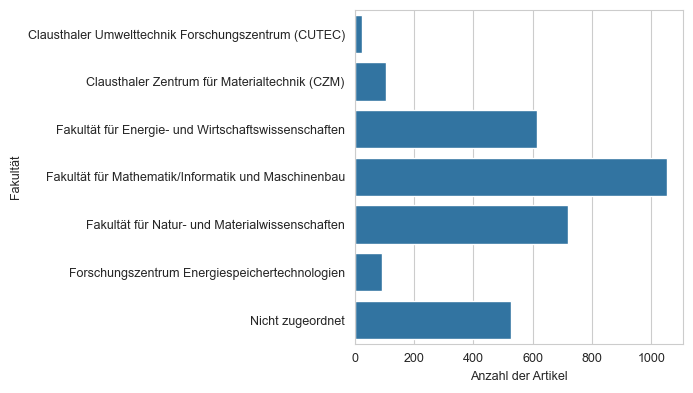

In [313]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [314]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8317935648295636